# **CIFAR-10 Classification Demo**

This Jupyter Notebook demonstrates the complete pipeline for training and evaluating a Convolutional Neural Network (CNN) for image classification on the CIFAR-10 dataset.

The project covers all key stages of a deep learning workflow, including data loading, model training, evaluation, and performance visualization.

Specifically, the notebook includes:

• Model training with a custom CNN / transfer learning (ResNet18)  
• Evaluation on a held-out test set  
• Loss and accuracy tracking over training epochs  
• Confusion matrix for class-wise performance analysis  
• Classification report (precision, recall, F1-score)  
• Example predictions with visual comparison  
• Multiclass ROC-AUC (One-vs-Rest strategy, macro-averaged across all classes)  
• ROC curves for each class


The goal of this project is to build a robust image classification system and provide a clear, interpretable analysis of model performance across all CIFAR-10 classes.

In [1]:
!git clone https://github.com/Pasha0923/project-cnn-classification.git
%cd project-cnn-classification
import sys
sys.path.append("/content/project-cnn-classification")
!ls models

Cloning into 'project-cnn-classification'...
remote: Enumerating objects: 149, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 149 (delta 50), reused 67 (delta 31), pack-reused 59 (from 1)
Receiving objects: 100% (149/149), 119.75 MiB | 15.61 MiB/s, done.
Resolving deltas: 100% (67/67), done.
/content/project-cnn-classification
best_model_2.pth  cnn_model.py	__init__.py


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix
from models.cnn_model import CIFAR10ResNet
from training.cifar10_loader import get_dataloaders
from configuration.config import DEVICE, MODEL_PATH, BATCH_SIZE


In [3]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 93.9 MB/s eta 0:00:00


In [9]:
# model training
!python -m training.train

100% 170M/170M [00:18<00:00, 9.09MB/s]
Epoch 1/12 [Train]: 100% 625/625 [02:56<00:00,  3.54it/s]
Epoch 1/12 [Val]: 100% 157/157 [00:18<00:00,  8.32it/s]
Epoch [1/12] | [TRAIN] Loss: 0.4263 | Acc: 85.77% || [VAL] Loss: 0.2197 | Acc: 92.68%
Best model saved (by accuracy)
Epoch 2/12 [Train]: 100% 625/625 [02:59<00:00,  3.48it/s]
Epoch 2/12 [Val]: 100% 157/157 [00:19<00:00,  8.14it/s]
Epoch [2/12] | [TRAIN] Loss: 0.1949 | Acc: 93.47% || [VAL] Loss: 0.1756 | Acc: 94.11%
Best model saved (by accuracy)
Epoch 3/12 [Train]: 100% 625/625 [02:59<00:00,  3.49it/s]
Epoch 3/12 [Val]: 100% 157/157 [00:18<00:00,  8.37it/s]
Epoch [3/12] | [TRAIN] Loss: 0.1342 | Acc: 95.48% || [VAL] Loss: 0.1598 | Acc: 94.59%
Best model saved (by accuracy)
Epoch 4/12 [Train]: 100% 625/625 [02:58<00:00,  3.51it/s]
Epoch 4/12 [Val]: 100% 157/157 [00:18<00:00,  8.30it/s]
Epoch [4/12] | [TRAIN] Loss: 0.1077 | Acc: 96.23% || [VAL] Loss: 0.1630 | Acc: 94.41%
Epoch 5/12 [Train]: 100% 625/625 [02:57<00:00,  3.52it/s]
Epoch 5/12

In [10]:
# download model
from google.colab import files
files.download("models/best_model_2.pth")
files.download("outputs/history.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# upload model in colab
from google.colab import files
uploaded = files.upload()

In [4]:
# model evaluation
!python -m training.evaluate

100% 170M/170M [00:13<00:00, 12.9MB/s]
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 94.9MB/s]
Test Accuracy: 95.75%


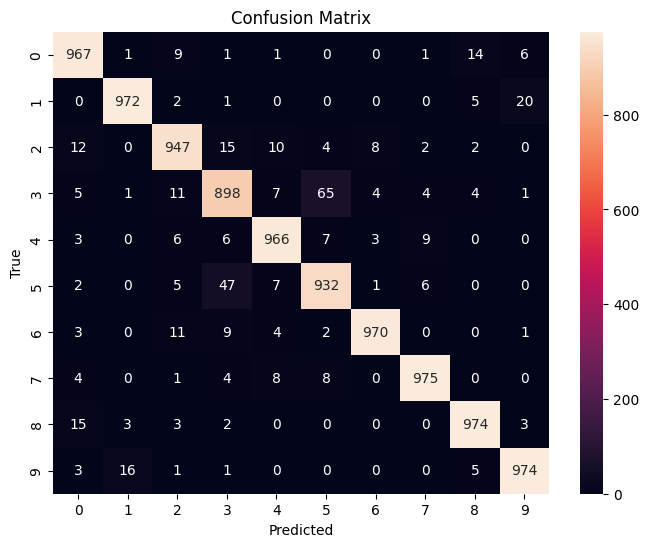

In [5]:
# Confusion matrix
_, _, test_loader = get_dataloaders(BATCH_SIZE)

model = CIFAR10ResNet().to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

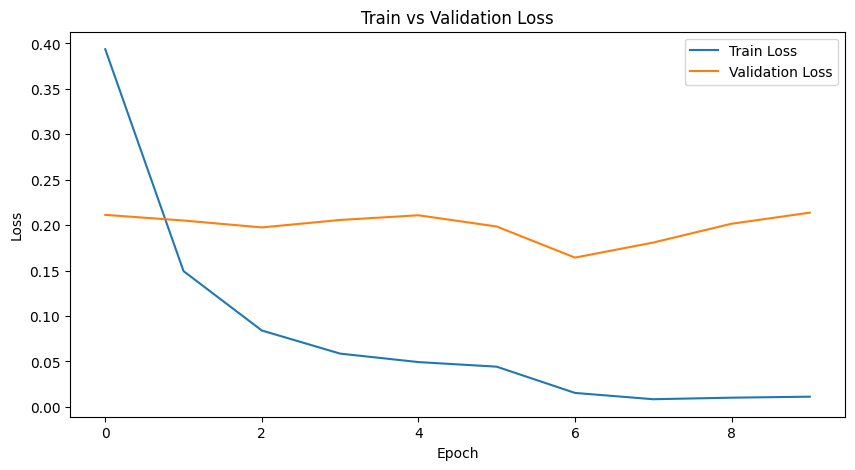

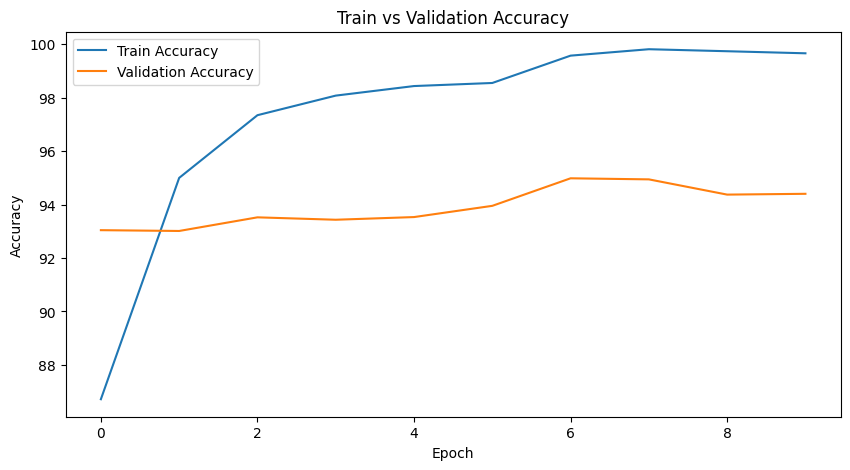

In [6]:
# LOSS / ACCURACY CURVES
import json
with open("outputs/history.json", "r") as f:
    history = json.load(f)

train_losses = history["train_losses"]
val_losses = history["val_losses"]
train_accuracies = history["train_accuracies"]
val_accuracies = history["val_accuracies"]

# LOSS PLOT
plt.figure(figsize=(10, 5))
plt.plot(train_losses,label='Train Loss')
plt.plot(val_losses,label='Validation Loss')
plt.title("Train vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# ACCURACY PLOT
plt.figure(figsize=(10, 5))
plt.plot(train_accuracies,label='Train Accuracy')
plt.plot(val_accuracies,label='Validation Accuracy')
plt.title("Train vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [7]:
# classification report
from sklearn.metrics import classification_report

classes = [
    'airplane','automobile','bird','cat','deer',
    'dog','frog','horse','ship','truck'
]

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=classes
    )
)

              precision    recall  f1-score   support

    airplane       0.95      0.97      0.96      1000
  automobile       0.98      0.97      0.98      1000
        bird       0.95      0.95      0.95      1000
         cat       0.91      0.90      0.91      1000
        deer       0.96      0.97      0.96      1000
         dog       0.92      0.93      0.92      1000
        frog       0.98      0.97      0.98      1000
       horse       0.98      0.97      0.98      1000
        ship       0.97      0.97      0.97      1000
       truck       0.97      0.97      0.97      1000

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



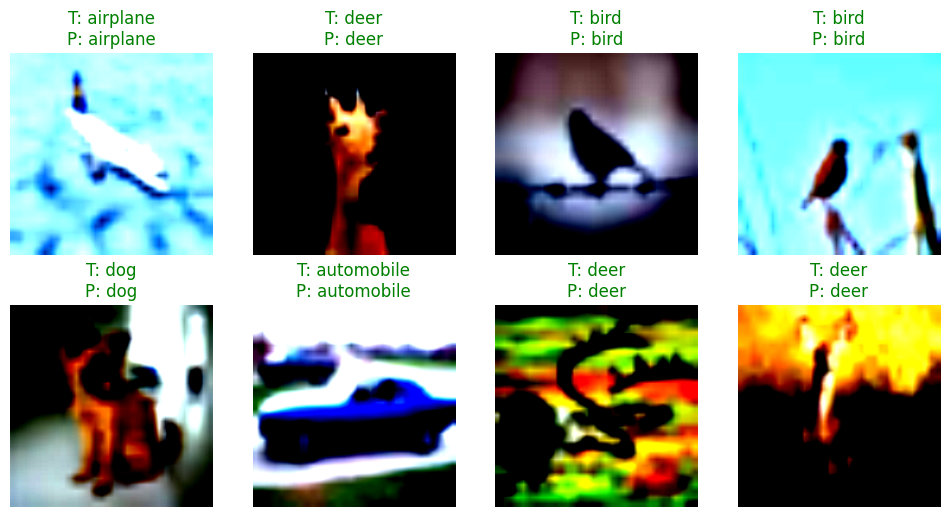

In [9]:
# prediction examples
indices = random.sample(range(len(test_loader.dataset)), 10)

images = []
labels = []

for idx in indices:
    img, label = test_loader.dataset[idx]
    images.append(img)
    labels.append(label)

images = torch.stack(images)
labels = torch.tensor(labels)

images = images.to(DEVICE)

# inference
with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

images = images.cpu()

# visualization
plt.figure(figsize=(12,6))

for i in range(8):
    plt.subplot(2,4,i+1)

    img = np.transpose(images[i], (1,2,0))
    plt.imshow(img)

    true_label = classes[labels[i]]
    pred_label = classes[preds[i].cpu()]

    color = "green" if preds[i] == labels[i] else "red"

    plt.title(f"T: {true_label}\nP: {pred_label}", color=color)
    plt.axis("off")

plt.show()

In [10]:
# Multiclass ROC-AUC (OvR, macro averaged across all classes)

classes = [
    'airplane','automobile','bird','cat','deer',
    'dog','frog','horse','ship','truck'
]

num_classes = len(classes)

all_probs = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

# one-hot encoding for labels
y_true_bin = label_binarize(all_labels, classes=range(num_classes))

# ================= ROC-AUC =================
roc_auc = roc_auc_score(y_true_bin, all_probs, average="macro", multi_class="ovr")

print(f"ROC-AUC (macro, OvR): {roc_auc:.4f}")

ROC-AUC (macro, OvR): 0.9985


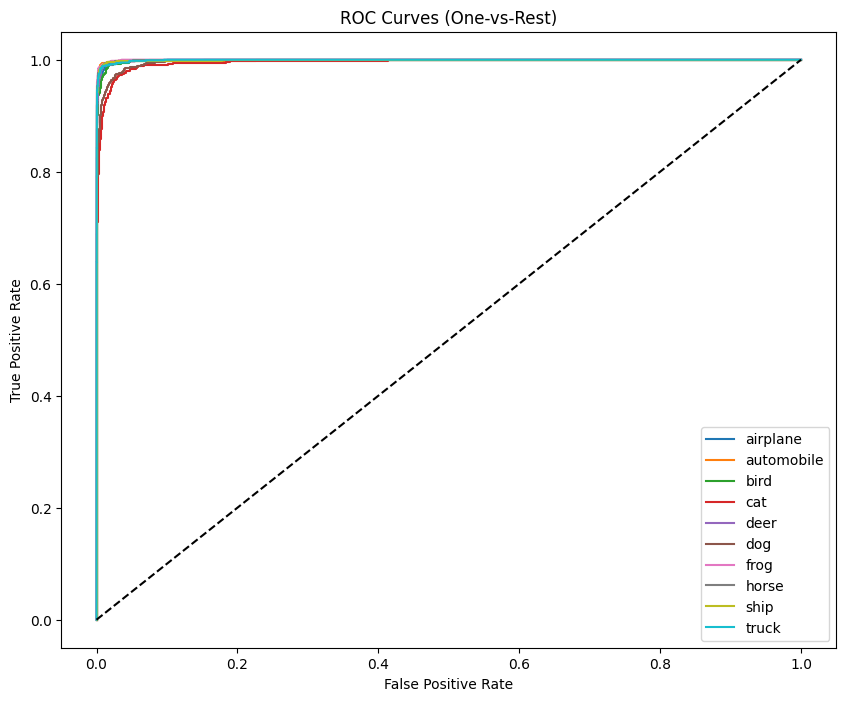

In [11]:
# ROC CURVES for each class
plt.figure(figsize=(10,8))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])

    plt.plot(fpr, tpr, label=f"{classes[i]}")

plt.plot([0,1], [0,1], "k--")

plt.title("ROC Curves (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# **Final Conclusions**

This project demonstrated the successful application of deep learning techniques for multiclass image classification on the CIFAR-10 dataset using a fine-tuned ResNet18 architecture.

The model achieved strong overall performance:

- Best Validation Accuracy: 96.09%
- Test Accuracy: 95.75%
- Macro ROC-AUC (OvR): 0.9983
- Macro F1-score: 0.95

The high ROC-AUC score indicates excellent separability between classes.
A macro-averaged One-vs-Rest (OvR) strategy was used in order to evaluate all classes equally, regardless of class frequency. Since CIFAR-10 is a multiclass classification problem, ROC-AUC cannot be computed directly in the same way as binary classification. Therefore, each class is evaluated against all remaining classes independently, and the final score is averaged across all classes.

Analysis of the learning curves demonstrates that the model converged successfully during training:

- training loss decreased steadily from approximately 0.39 to nearly 0.01
- validation accuracy improved consistently and stabilized around 96%
- no severe overfitting was observed despite the very high training accuracy

The resulting system provides accurate and reliable image classification performance on the CIFAR-10 dataset and serves as a strong example of a modern computer vision workflow using PyTorch.